### 6/23/26 just checking to see if the output is normal

## Background

The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

Note that a general equation for the diascalar material transformation for a process $P$ for a water mass $\mathcal{M}$ defined to be all tracer $\lambda$ values greater than $\tilde \lambda$. The convergence of a flux $\mathcal{F} = \nabla \cdot \mathbf{F}$.

$$
    \mathcal{G}_{\ge}^{\text{(P)}} = \int_{\mathcal{A_R}(\tilde\lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \mathcal{F} \, \text{d}S = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
$$

And the subsequent diascalar material transformation demonstrating a relationship between mixing calculated as a convergence of a diffusive flux and mixing calculated as tracer variance decay is

*tbh, idk if this is the equation they use, but this is the equation I derived in my advancement proposal*
$$
\begin{equation}
\mathcal{G}^{\text{(phy)}} = \underbrace{\int_{\mathcal{A_R}(\tilde \lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \left(- \nabla \cdot \left(-\kappa_{phy} \nabla \lambda\right)\right) \, \text{d}S}_{\text{mixing as conv. of diff. flux}} = \underbrace{-\frac{1}{2} \frac{\partial^2}{\partial \tilde\lambda^2}\left[ \int_{\Omega(\tilde\lambda ,t)} \rho \left( 2 \kappa_{phy} \vert\vert \nabla \lambda \vert\vert^2\right) \, \text{d}V\right]}_{\text{mixing as var. decay}} 
\tag{2}
\end{equation}
$$ 


While Castro et al. describes a relationship between the convergence of a diffusive tracer flux and tracer variance decay for *phyiscal* mixing, we propose to look at *numerical* mixing through a similar framework. This relationship would look very similar to Equation 2, but our we would instead be solving for the term $\mathcal{G}^{\text{(num)}}$ and the diffusivities would be $\kappa_{num}$ rather than $\kappa_{phy}$. 

### Mixing as convergence of a diffusive flux
We quickly run into a problem, which is that $\kappa_{num}$ is unknown when calculating the nuemrical mixing as the convergence of a diffusive flux. Recall that $\kappa_{phy}$ comes from a prescribed background diffusivity. In which case, we need a different way to calculate $\mathcal{G}^{\text{(num)}}$. We propose to do so using the WMT budget residual.

$$
\begin{align}
    \partial_t{\mathcal{M}} &= \Psi + \mathcal{S} + \mathcal{G^{\text{(BF)}}} + \mathcal{G^{\text{(phy)}}} + \mathcal{G^{\text{(num)}}} \\
    \implies \mathcal{G^{\text{(num)}}} & = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}}
    \tag{3}
\end{align} 
$$

### Mixing as tracer variance decay
We *can*, however, calculate a $\kappa_{num}$ when thinking about numerical mixing through the perspective of tracer variance decay, if we use the Discrete Varaince Decay (DVD) algorithm.
Let 
$$
\begin{equation}
	\chi^{\text{(num)}} = \underbrace{\frac{A\{\left(\lambda_i^n\right)^2\} -\left[A\{\lambda_i^n\}\right]^2}{\Delta t}}_{\text{DVD}} = \underbrace{-2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}}_{\substack{\text{discretized mixing}\\\text{as variance decay}}} \approx \underbrace{-2 \kappa_{num}\left(\frac{\partial \lambda}{\partial x}\right)^2}_{\substack{\text{continuous mixing}\\\text{as variance decay}}} \tag{4}
\end{equation}
$$

The $\kappa_{num}$ arises out of the mathematical manipulation of the advection operator to get the rest of thet algorithm.
$$
    \kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x}\right) \tag{5}
$$

The $\chi^{\text{(num)}}$ term is a tendency that can now be written in the WMT framework as 
$$
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
$$

### WMT relationship of numerical mixing as a budget residual and as tracer variance decay.
The following relationship (in terms of the WMT framework) between Equations 2 and 3 then emerges.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi \, \text{d}V\right] \tag{7}
\end{equation}
$$

*do NOT trust the signs in this argument, it depends on the direction you're integrating, and I'm sure I have several sign errors rn*

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

### Open files & visualize raw data

In [2]:
# filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
# ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
# ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
# ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
# mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
# descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [3]:
# # could also calculate density, since we know bichan uses a linear eos
# def calculate_leos(ds_output, alpha = 1.7e-4, beta = 7.6e-4, eos_densityref = 1000):
#     rho = eos_densityref * (1 - (alpha * ds_output.temperature) + (beta * ds_output.salinity))

#     return rho

In [4]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

# format ds_dvd so that it includes a time=0 index (otherwise missing first time step)
ds_dvd = xr.concat([ds_dvd.isel(Time=0), ds_dvd],dim='Time')
ds_dvd["xtime"][0]= np.array(b"0001-01-01_00:00:00", dtype="|S64")

ds_dvd['xtime'] = ds_dvd.xtime.assign_attrs(description='time=0 data is copy of time=1')

# interpolate the DVD vertical physical mixing onto nVertLevels
grid_dvd = Grid(ds_dvd, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)
ds_dvd['chiPhyVerTemp_center'] = grid_dvd.interp(ds_dvd.chiPhyVerTemp, 'Z' ,boundary = 'extend')
ds_dvd['chiPhyVerSalt_center'] = grid_dvd.interp(ds_dvd.chiPhyVerSalt, 'Z', boundary = 'extend')

# ffill (good practice but not applicable here because no bathymetry)
ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# merge datasets
ds_output = xr.merge([ds_dvd, ds_output])

# set time index
time_idx = 115

In [5]:
for i in ds_output.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


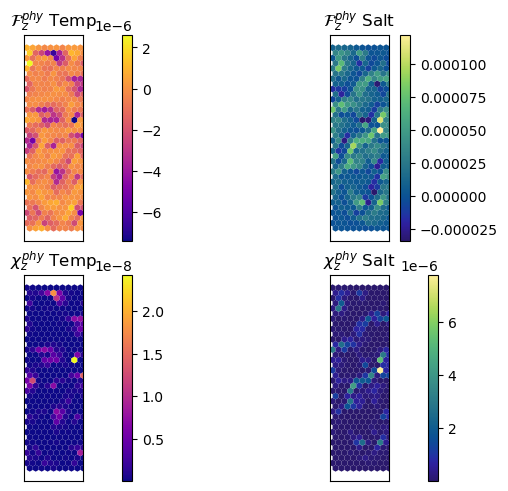

In [6]:
# comparison of mixing
fig,ax = plt.subplots(nrows=2, ncols = 2, constrained_layout=True)

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0,0],descriptor, ds_output.temperatureVertMixTendency.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
b = mosaic.polypcolor(ax[0,1],descriptor, ds_output.salinityVertMixTendency.isel(Time=time_idx, nVertLevels=0),cmap='cmo.haline')
ax[0,0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[0,1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')

# calculated as tracer variance decay
c = mosaic.polypcolor(ax[1,0],descriptor, ds_dvd.chiPhyVerTemp_center.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
d = mosaic.polypcolor(ax[1,1],descriptor, ds_dvd.chiPhyVerSalt_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.haline')
ax[1,0].set_title(r'$\chi_z^{phy}$ Temp')
ax[1,1].set_title(r'$\chi_z^{phy}$ Salt')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_aspect(1.0)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

fig.colorbar(a, ax = ax[0,0])
fig.colorbar(b, ax = ax[0,1])
fig.colorbar(c, ax = ax[1,0])
fig.colorbar(d, ax = ax[1,1])

## Explanation of data


|Dataset Name|Description|
|--| --|
|`ds_output` | standard output variables (T, S, velo)|
|`ds_dvd` | $\chi^{\text{(phy)}}$ and $\chi^{\text{(num)}}$ from DVD alg.|
|`ds_output` | $\mathcal{F} \,; [^\circ C s^{-1}]$ ; conv. of diff. flux |
|`mesh` | grid variables (cellsOnEdge, etc) |

>- Simulations were run with a linear equation of state such that $\rho_0 = 1027 \, kg/m^3$ $\leftarrow$ CHECK THIS 
>- No prescribed horizontal mixing $\kappa_{phy,x} = 0$, so we expect `TracerHorMixTendency` to be 0 (`ds_output` dataset).
>- Vertical mixing is prescribed using KPP where the background diffusivity is $\kappa_{phy,z} = 10e-5 \, m^2s^{-1}$.
>- The background viscosity is set to $\nu = 10e-4 \, m^2 s^{-1}$.
>- Only wind stress forcing is prescribed.
>- The `TracerSurfaceFluxTendency` in the `ds_output` dataset is 0 because we do not have any boundary forcing that would introduce tracers at the surface.
>- `potentialDensity` is reference to the middle of the top cell. So in this idealized caase, `potentialDensity` = `density`

The $\mathcal{F}$ and $\chi$ outputs require that we calculate $\mathcal{G}^{\text{(phy)}}$ and $\mathcal{G}^{\text{(num)}}$ offline. The following math is necessary.

*Recall that in order to calculate the residual, we need to directly calculate all other terms in the budget*

We need to plug in $\mathcal{F}$ (`TracerVertMixTendency`) into Equation 1.
$$
\begin{equation}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \,\text{d} V\right] \tag{1}
\end{equation}
$$

We need to plug in $\chi^{\text{(num)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
\end{equation}
$$

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

*I think this is what also eliminates the negative sign in $\mathcal{G}^{\text{(phy)}}$.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class.

## Calculate $\mathcal{G}_\chi^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

### Note these are slightly different signs than the earlier equation box. This is because of how we defined $\mathcal{M}_\ge$, which adds a negative sign, since we are interested in how water is being transformed into masses with $\lambda > \tilde\lambda$... I think (6/30/26)

### Non-generalized functions for calculating $\mathcal{G}^\text{(phy)}$

In [7]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # calculate the integrand
    dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
    tendency = ds_output[F_variable] * dV

    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels

    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            periodic = False, 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', boundary = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand (currently sitting on center nVertLevels) to salinity_P1 coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})

    # recall that we define the mass to be M>=, so we need to take the cumulative sum from bottom to top to get 
    # the full mixing per salinity class, which means the mixing for \tilde\lambda surfaces AND all \lambda surfaces greater than \tilde\lambda
    
    # reverse the direction of salinity_P1 (now greatest to lowest)
    # then take the cumulative sum of tendency from greatest salinity to lowest salinity 
    # then reverse the direction of salinity_P1 again 
    da_F_volume_int_tendency_transformed  = da_F_tendency_transformed.isel(salinity_P1 = 
                                                                          slice(None, None, -1)).cumsum(dim='salinity_P1').isel(salinity_P1 = 
                                                                                                                                slice(None, None, -1))

    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    # the transform remapped the datavariable to the CENTER of the cell 
    # rename the salinity_P1 coords to salinity
    ds_F_volume_int_tendency_transformed = ds_F_volume_int_tendency_transformed.rename({'salinity_P1' : 'salinity'})
    
    # add back the salinity_P1 coordinates
    ds_F_volume_int_tendency_transformed = ds_F_volume_int_tendency_transformed.assign_coords({'salinity_P1' : target_coords_P1})
    
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

    # then calculate the derivative d_integrand
    # create an array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords_P1) - 2):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed[
                                    'cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed[
                                    'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = (d_tracerMassFlux / dlambda) * -1e3 # salinityMixTendency has units of 1e-3 / s, need to convert to compare
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # this eliminates the first and last entry in salinity_P1 coords
    salinity_P1_trimmed = target_coords_P1[1:-1]
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    
    # add back salinity_coords
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    
    G_F_phy_ds = G_F_phy_ds.assign_coords({'salinity' : salinity_trimmed})

    # remap to get onto matching salinity coordinates
    # make a grid that identifies salinity as the vertical coordinates
    grid_salinity = Grid(G_F_phy_ds, coords={'Z': {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        periodic = False,
                        autoparse_metadata = False)
    
    G_F_phy_ds['G_F_phy_center'] = grid_salinity.interp(G_F_phy_ds.G_F_phy, 'Z', boundary='extend')
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])

    return G_F_phy_ds

In [66]:
# write function to calculate G_F_phy
F_variable = 'salinityVertMixTendency'
rho_0 = 1026
target_coord_spacing = 0.25
# def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # calculate the integrand
dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
tendency_F = ds_output[F_variable] * dV

# Remap to salinity coordinates
# to conservatively remap with xgcm:
# >- datavariables must sit on cell centers
# >- must supply cell edges to calculate remap
# >- datavariable will be transformed onto cell center
# So we must
# >- ensure datavariable sits on salinity to begin with
# >- supply outer (P1) coordinate for the transformation
# >- transform such that the datavariable sits on salinity and not nVertLevels

# set up salinity data to be target coords
# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# calculate target salinity coordinates (salinity_P1)
# interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)

ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', boundary = 'extend')

# +2 to ensure that the upper and lower bins have a Gphy = 0
lower_bound = ds_output.salinity_P1.min() - 2
upper_bound = ds_output.salinity_P1.max() + 2
target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

# transform integrand (currently sitting on center nVertLevels) to salinity_P1 coordinates
da_F_tendency_transformed = grid_nVertLevels.transform(tendency_F, # data we want to transform (on cell centers)
                                                       'Z', # axis of transformation
                                                       target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                       method = 'conservative', # method
                                                       target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned


In [67]:
for i in range(0,721):
    diff = da_F_tendency_transformed.isel(Time=i).sum() - tendency_F.isel(Time=i).sum()
    if np.abs(diff) > 1:
        print('Time_idx where tendency is not conserved ', i)

diff_array= ([])
for i in range(0,360):
    diff = da_F_tendency_transformed.isel(Time=0, nCells=i).sum() - tendency_F.isel(Time=0,nCells=i).sum()
    if np.abs(diff) > 1:
        print('nCells_idx = ', i)
        diff_array = np.append(diff_array, diff)
print('total difference = ', np.sum(diff_array))


total difference =  0.0


In [36]:
# rho_0 = 1026
# target_coord_spacing = 0.25
# # your chi_variable should sit on cell centers
# chi_variable = 'chiPhyVerSalt_center'

def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print('Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print('Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * mesh.layerThickness.isel(Time=0)
    
    tendency = rho_0 * ds_output[chi_variable] * dV
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # +2 to ensure that the upper and lower bins have Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # transform chi data from nVertLevels coord to salinity coord
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                periodic = False,
                autoparse_metadata = False)
    
    da_chi_tendency_transformed = grid.transform(tendency, # currently sitting on cell centers
                                                  'Z',
                                                  target_coords_P1, # consersvative remap requires specifying target edge coords
                                                  method = 'conservative',
                                                  target_data = ds_output.salinity_P1)  # corresponding actual coords to be binned in target_coords)
    
    # recall that we define the mass to be M>=, so we need to take the cumulative sum from bottom to top to get 
    # the full mixing per salinity class, which means the mixing for \tilde\lambda surfaces AND all \lambda surfaces greater than \tilde\lambda
    
    # reverse the direction of salinity_P1 (now greatest to lowest)
    # then take the cumulative sum of tendency from greatest salinity to lowest salinity 
    # then reverse the direction of salinity_P1 again 
    da_chi_volume_int_tendency_transformed  = da_chi_tendency_transformed.isel(salinity_P1 = 
                                                                          slice(None, None, -1)).cumsum(dim='salinity_P1').isel(salinity_P1 = 
                                                                                                                                slice(None, None, -1))

    # convert from dataarray to dataset
    ds_chi_volume_int_tendency_transformed = da_chi_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + chi_variable)
    
    # transform remapped the datavariable to the CENTER of the cell
    # rename the salinity_P1 coords to salinity
    ds_chi_volume_int_tendency_transformed = ds_chi_volume_int_tendency_transformed.rename({'salinity_P1' : 'salinity'})

    # # check the transformation 7/7
    # diff = ds_chi_volume_int_tendency_transformed.sum() - tendency.sum()
    # if diff > 10:
    #     print('not conserved')
    # else:
    #     print('conserved')
    
    # calculate the first derivative (d_integrand / d_lambda)
    mixingFlux = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i - i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    for i in range(0,len(target_coords_P1)-2):
        d_mixing = ds_chi_volume_int_tendency_transformed[
                    'cumulative_vol_int_tendency_' + chi_variable][:,:,i] - ds_chi_volume_int_tendency_transformed[
                    'cumulative_vol_int_tendency_' + chi_variable][:,:,i+1]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class 
        mixingFlux.append(d_mixing_d_lambda)
    
    # convert mixingFlux to dataarray
    mixingFlux_da = xr.concat(mixingFlux, dim='salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingFlux_da[i,:,:] - mixingFlux_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})

    return G_chi_mix_ds

In [71]:
rho_0 = 1026
target_coord_spacing = 0.25
# your chi_variable should sit on cell centers
chi_variable = 'chiPhyVerSalt_center'
chi_variable = 'chiSpurSaltBR08'

# def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
if 'BR08' in chi_variable:
    mixing_type = 'num'
    print('Calculating G_chi_num')
if 'Phy' in chi_variable:
    mixing_type = 'phy'
    print('Calculating G_chi_phy')

# calculate the integrand
dV = mesh.areaCell * mesh.layerThickness.isel(Time=0)

tendency_chi_num = rho_0 * ds_output[chi_variable] * dV
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# +2 to ensure that the upper and lower bins have Gphy = 0
lower_bound = ds_output.salinity_P1.min() - 2
upper_bound = ds_output.salinity_P1.max() + 2
target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)

d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array

# transform chi data from nVertLevels coord to salinity coord
grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
            periodic = False,
            autoparse_metadata = False)

da_chi_num_tendency_transformed = grid.transform(tendency_chi_num, # currently sitting on cell centers
                                              'Z',
                                              target_coords_P1, # consersvative remap requires specifying target edge coords
                                              method = 'conservative',
                                              target_data = ds_output.salinity_P1)  # corresponding actual coords to be binned in target_coords)

Calculating G_chi_num


In [72]:
for i in range(0,721):
    diff = da_chi_num_tendency_transformed.isel(Time=i).sum() - tendency_chi_num.isel(Time=i).sum()
    if np.abs(diff) > 1:
        print('Time_idx where tendency is not conserved ', i)

Time_idx where tendency is not conserved  0


In [73]:
diff_array= ([])
for i in range(0,360):
    diff = da_chi_num_tendency_transformed.isel(Time=0, nCells=i).sum() - tendency_chi_num.isel(Time=0,nCells=i).sum()
    if np.abs(diff) > 1:
        print('nCells_idx = ', i)
        diff_array = np.append(diff_array, diff)
print('total difference = ', np.sum(diff_array))


nCells_idx =  0
nCells_idx =  1
nCells_idx =  2
nCells_idx =  3
nCells_idx =  4
nCells_idx =  5
nCells_idx =  6
nCells_idx =  7
nCells_idx =  8
nCells_idx =  9
total difference =  65191516.46224201


In [77]:
rho_0 = 1026
target_coord_spacing = 0.25
# your chi_variable should sit on cell centers
chi_variable = 'chiPhyVerSalt_center'

# def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
if 'BR08' in chi_variable:
    mixing_type = 'num'
    print('Calculating G_chi_num')
if 'Phy' in chi_variable:
    mixing_type = 'phy'
    print('Calculating G_chi_phy')

# calculate the integrand
dV = mesh.areaCell * mesh.layerThickness.isel(Time=0)

tendency_chi_phy = rho_0 * ds_output[chi_variable] * dV
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# +2 to ensure that the upper and lower bins have Gphy = 0
lower_bound = ds_output.salinity_P1.min() - 2
upper_bound = ds_output.salinity_P1.max() + 2
target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)

d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array

# transform chi data from nVertLevels coord to salinity coord
grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
            periodic = False,
            autoparse_metadata = False)

da_chi_phy_tendency_transformed = grid.transform(tendency_chi_phy, # currently sitting on cell centers
                                              'Z',
                                              target_coords_P1, # consersvative remap requires specifying target edge coords
                                              method = 'conservative',
                                              target_data = ds_output.salinity_P1)  # corresponding actual coords to be binned in target_coords)

Calculating G_chi_phy


In [78]:
for i in range(0,721):
    diff = da_chi_phy_tendency_transformed.isel(Time=i).sum() - tendency_chi_phy.isel(Time=i).sum()
    if np.abs(diff) > 1:
        print('Time_idx where tendency is not conserved ', i)

Time_idx where tendency is not conserved  0


In [79]:
diff_array= ([])
for i in range(0,360):
    diff = da_chi_phy_tendency_transformed.isel(Time=0, nCells=i).sum() - tendency_chi_phy.isel(Time=0,nCells=i).sum()
    if np.abs(diff) > 1:
        print('nCells_idx = ', i)
        diff_array = np.append(diff_array, diff)
print('total difference = ', np.sum(diff_array))


nCells_idx =  0
nCells_idx =  1
nCells_idx =  2
nCells_idx =  3
nCells_idx =  4
nCells_idx =  5
nCells_idx =  6
nCells_idx =  7
nCells_idx =  8
nCells_idx =  9
total difference =  242.9069418916337


In [9]:
# wrapper function to perform all calculations
def calculate_G_mix(rho_0, mesh, ds_output, target_coord_spacing = 1):
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, ds_output,target_coord_spacing)
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, ds_output,target_coord_spacing)
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, ds_output,target_coord_spacing)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    G_phy_comp_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, G_phy_comp_ds

In [10]:
# calculate transformation at every density class
def vertical_cumsum(G_phy_ds, variable, reduce_time_dim_method, time_idx=0):

    if reduce_time_dim_method == 'average':
        G_phy = G_phy_ds[variable].mean(dim='Time').sum(dim='nCells')

    if reduce_time_dim_method == 'isel':
        G_phy = G_phy_ds[variable].isel(Time = time_idx).sum(dim='nCells')
        
    # cumsum from bottom (lowest salinity class) to top (highest salinity class)
    # we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
    # reduce G_phy_ds along several dimensions
    
    rev_G_phy = np.flipud(G_phy)
    cumsum_rev_G_phy = np.cumsum(rev_G_phy)
    # reverse back to match highest salinity value to lowest cumsum value
    cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

    print('reduced time dimension by ', reduce_time_dim_method)
    if reduce_time_dim_method == 'isel':
        print('time_idx = ', time_idx)

    return G_phy, cumsum_G_phy

In [11]:
## figure out at what salinity are the minima and maxima located for G_F_phy and G_chi_phy

def find_min_max_idx(da):
    # max if G_i > G_i+1 and G_i > G_i-1
    maxima_indices = np.where((da[1:-1] > da[:-2]) & (da[1:-1] > da[2:]))[0] + 1
    print('maxima at ', da[maxima_indices])
    
    # min if G_i < G_i+1 and G_i < Gi-1
    minima_indices = np.where((da[1:-1] < da[:-2]) & (da[1:-1] < da[2:]))[0] + 1
    print('minima at ' , da[minima_indices])

    return maxima_indices, minima_indices

-------
--------

In [37]:
rho_0 = 1026

G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, G_phy_comp_ds = calculate_G_mix(rho_0, mesh, ds_output, target_coord_spacing = 1)

Calculating G_chi_phy
not conserved
Calculating G_chi_num
not conserved


In [13]:
# remap the salinity tendency into salinity coordinates
grid_output = Grid(ds_output, coords = {'Z' : {'center': 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                    periodic = False,
                    autoparse_metadata = False)


ds_dt = grid_dvd.transform(ds_output.salinityTend,
                           'Z',
                           G_phy_comp_ds.salinity_P1,
                           method = 'conservative',
                           target_data = ds_output.salinity_P1)
ds_dt = ds_dt.to_dataset(name='salinityTend').rename({'salinity_P1' : 'salinity'})

In [14]:
# find dM/dt
# create grid to allow for transformation to salinity coords
ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# +2 to ensure that the upper and lower bins have Gphy = 0
target_coord_spacing = 1
lower_bound = ds_output.salinity_P1.min() - 2
upper_bound = ds_output.salinity_P1.max() + 2
target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)

grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            periodic = False, 
                            autoparse_metadata=False)
# mass of every grid cell in z coords
mass = ds_output.density * ds_output.layerThickness * mesh.areaCell

# then remap into salinity space
vert_int_mass_transform = grid_nVertLevels.transform(mass,
                                            'Z',
                                            target_coords_P1,
                                            method = 'conservative',
                                            target_data = ds_output.salinity_P1)

vert_int_mass_transform = vert_int_mass_transform.rename({'salinity_P1' : 'salinity'})

# then calculate then vertical cumulative sum
vert_int_mass = vert_int_mass_transform.isel(salinity = slice(None,None,-1)).cumsum(dim='salinity').isel(salinity = slice(None,None,-1))

In [15]:
for i in range(0,721):
    diff = vert_int_mass_transform.isel(Time=i).sum() - mass.isel(Time=i).sum()
    if np.abs(diff) > 1:
        print(i)

0


In [16]:
diff_array= ([])
for i in range(0,360):
    diff = vert_int_mass_transform.isel(Time=0, nCells=i).sum() - mass.isel(Time=0,nCells=i).sum()
    if np.abs(diff) > 1:
        print('nCells_idx = ', i)
        diff_array = np.append(diff_array, diff)
print('total difference = ', np.sum(diff_array))


nCells_idx =  0
nCells_idx =  1
nCells_idx =  2
nCells_idx =  3
nCells_idx =  4
nCells_idx =  5
nCells_idx =  6
nCells_idx =  7
nCells_idx =  8
nCells_idx =  9
total difference =  42478783969465.96


In [17]:
(vert_int_mass_transform.sum() - mass.sum()) - np.sum(diff_array)
# these 10 cells at time = 0 almost completely account for the difference in total mass before and after transformation.

<xarray.DataArray ()> Size: 8B
array(-57.9609375)

In [32]:
ds_output.salinity - ds_output.salinity_P1

<xarray.DataArray (Time: 721, nCells: 360, nVertLevels: 50, nVertLevelsP1: 51)> Size: 3GB
array([[[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
          -4.38995361e-02, -1.10755920e-01, -1.33712769e-01],
         [ 1.97913818e+01,  1.97911644e+01,  1.97907295e+01, ...,
           4.39033508e-02, -2.29530334e-02, -4.59098816e-02],
         [ 1.98372917e+01,  1.98370743e+01,  1.98366394e+01, ...,
           8.98132324e-02,  2.29568481e-02,  0.00000000e+00]],

        [[ 0.00000000e+00, -1.44958496e-04, -4.11987305e-04, ...,
          -1.97012100e+01, -1.97579041e+01, -1.97768974e+01],
         [ 2.86102295e-04,  1.41143799e-04, -1.25885010e-04, ...,
          -1.97009239e+01, -1.97576180e+01, -1.97766113e+01],
         [ 5.37872314e-04,  3.92913818e-04,  1.25885010e-04, ...,
          -1.97006721e+01, -1.97573662e+01, -1.97763596e+01],
         ...,
         [ 1.96635056e+01,  1.96633606e+01,  1.96630936e+01, ...,
          -3.77044678e-02, -9.43984985e-02, -1.13391876e-01],
         [ 1.97389145e+01,  1.97387695e+01,  1.97385025e+01, ...,
           3.77044678e-02, -1.89895630e-02, -3.79829407e-02],
         [ 1.97768974e+01,  1.97767525e+01,  1.97764854e+01, ...,
           7.56874084e-02,  1.89933777e-02,  0.00000000e+00]]]],
      shape=(721, 360, 50, 51), dtype=float32)
Dimensions without coordinates: Time, nCells, nVertLevels, nVertLevelsP1

In [27]:
transform_10nCells = grid_nVertLevels.transform(mass.isel(Time=0,nCells=slice(0,10)),
                                                'Z',
                                                target_coords_P1,
                                                method = 'conservative',
                                                target_data = ds_output.salinity_P1.isel(Time=0, nCells=slice(0,10)))
transform_theRest = grid_nVertLevels.transform(mass.isel(nCells=slice(10,360)),
                                                'Z',
                                                target_coords_P1,
                                                method = 'conservative',
                                                target_data = ds_output.salinity_P1.isel(nCells=slice(10,360)))

In [31]:
# compare the rest of the cells (not nCells 0-10)
print('nCells 10-360: diff = ', (transform_theRest.sum() - mass.isel(nCells = slice(10,360)).sum()).values) 

# compare the transformed first 10 cells
print('nCells 0-10: diff = ', (transform_10nCells.sum() - mass.isel(Time=0,nCells=slice(0,10)).sum()).values)

nCells 10-360: diff =  0.0
nCells 0-10: diff =  42478783969465.97


In [16]:
# calculate dM>= / dt
# take the sum of vertical cumsums (all mass below the surface for all nCells)
dM = vert_int_mass.diff(dim = 'Time')
dt = 2 * 60 * 60 # dt = 2 hrs, need to get into units of seconds
dM_dt = (dM / dt).transpose('salinity','nCells','Time')

# from dM/dt, calculate the residual numerical mixing
# interpolate G_phy_comp_ds.G_F_phy_center onto "outer/edge" time steps
G_F_outer_time = (G_phy_comp_ds.G_F_phy_center[:,:,1:] + G_phy_comp_ds.G_F_phy_center[:,:,:-1]) / 2

G_F_num = dM_dt - G_F_outer_time

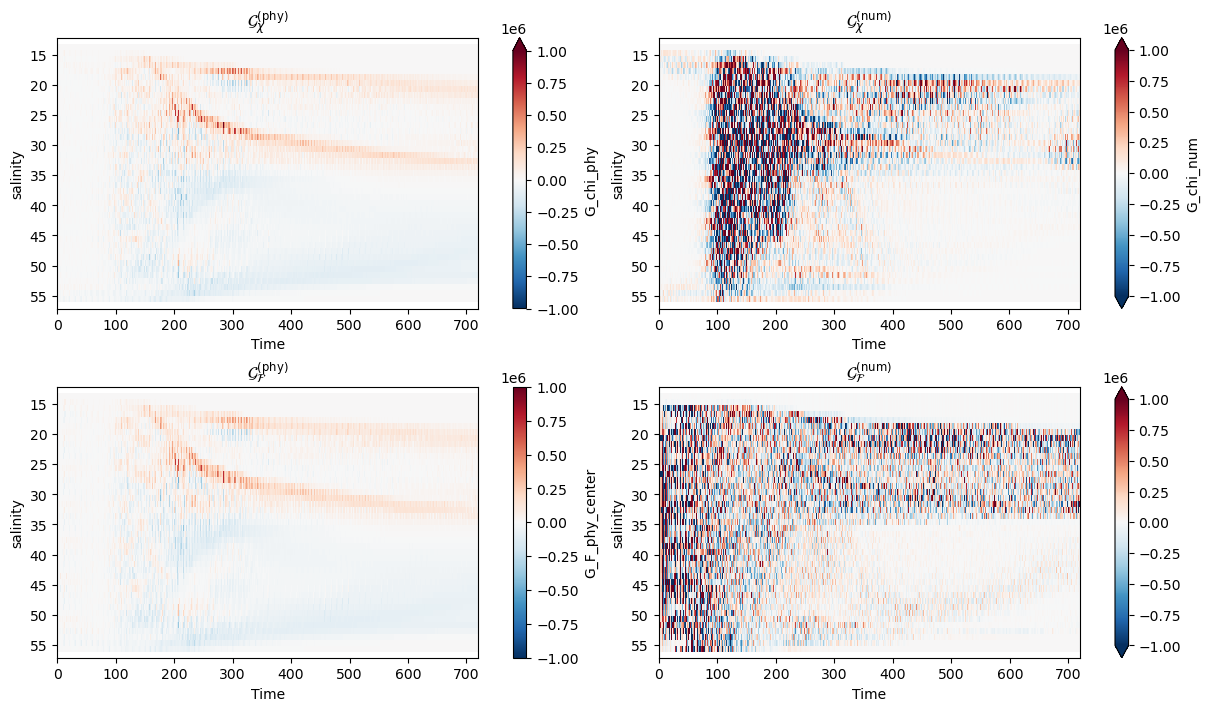

In [17]:
fig, ax = plt.subplots(nrows=2,ncols=2,constrained_layout=True,figsize=(12,7))

G_phy_comp_ds.G_chi_phy.mean(dim='nCells').plot(ax=ax[0,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
G_phy_comp_ds.G_chi_num.mean(dim='nCells').plot(ax=ax[0,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

G_phy_comp_ds.G_F_phy_center.mean(dim='nCells').plot(ax=ax[1,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
G_F_num.mean(dim='nCells').plot(ax=ax[1,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

Text(0.5, 1.0, 'Time-averaged WMT budget for $\\mathcal{M}_{\\geq}$')

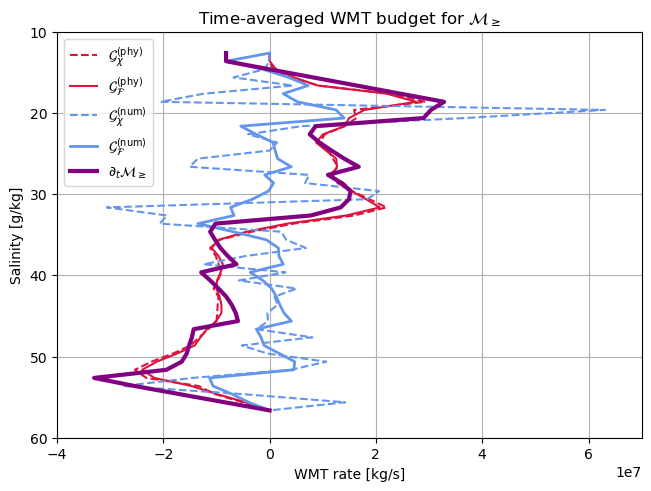

In [18]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)

# G_phy
G_phy_comp_ds.mean(dim='Time').sum('nCells').G_chi_phy.plot(y='salinity',label = r'$\mathcal{G}_\chi^{\text{(phy)}}$', 
                                                            linestyle='dashed', color='crimson')
G_phy_comp_ds.mean(dim='Time').sum('nCells').G_F_phy_center.plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$', color = 'crimson')

# G_num
G_phy_comp_ds.mean(dim='Time').sum('nCells').G_chi_num.plot(y='salinity', label = r'$\mathcal{G}_\chi^{\text{(num)}}$', 
                                                            linestyle='dashed',color='cornflowerblue')
G_F_num.mean(dim='Time').sum('nCells').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$',linewidth = 2, color='cornflowerblue')
# ds_dt.mean(dim='Time').sum('nCells').salinityTend.plot(y='salinity', label = r'$\partial_t \lambda$')

# dM/dt
dM_dt.sum('nCells').mean(dim='Time').plot(y='salinity',label = r'$\partial_t \mathcal{M}_{\geq}$', color='purple',linewidth = 3)

ax.grid()
ax.set_ylim(10,60)
ax.set_xlim(-4e7, 7e7)
ax.legend()
ax.invert_yaxis()
ax.set_xlabel('WMT rate [kg/s]')
ax.set_ylabel('Salinity [g/kg]')
ax.set_title(r'Time-averaged WMT budget for $\mathcal{M}_{\geq}$')

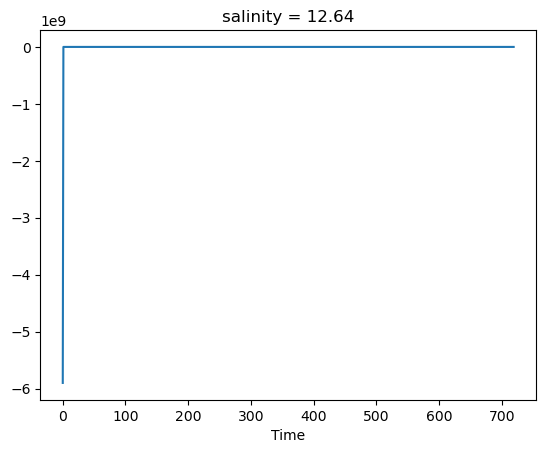

In [19]:
dM_dt.sum(dim='nCells').isel(salinity=0).plot()

In [32]:
ds_output.salinity_P1.min()

<xarray.DataArray 'salinity_P1' ()> Size: 8B
array(14.1367588)

In [31]:
ds_output.salinity.min()

<xarray.DataArray 'salinity' ()> Size: 8B
array(14.1367588)

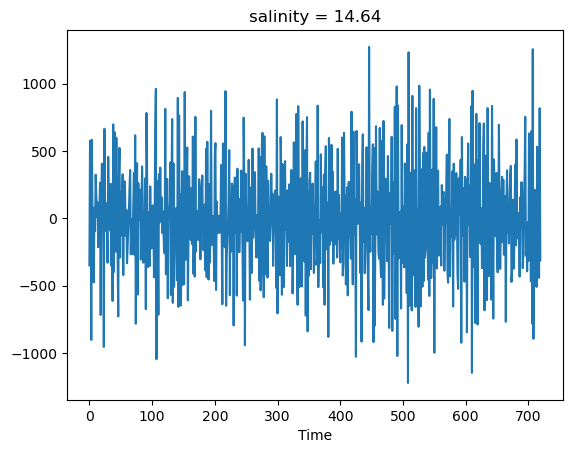

In [28]:
dM_dt.sum(dim='nCells').isel(salinity=2).plot()

In [62]:
G_F_phy_avg, cumsum_G_F_phy_avg = vertical_cumsum(G_phy_comp_ds, 'G_F_phy_center', 'average')

reduced time dimension by  average


In [63]:
G_F_phy_isel, cumsum_G_F_phy_isel = vertical_cumsum(G_phy_comp_ds, 'G_F_phy_center', 'isel', time_idx)

reduced time dimension by  isel
time_idx =  115


In [64]:
G_chi_phy_avg, cumsum_G_chi_phy_avg = vertical_cumsum(G_phy_comp_ds, 'G_chi_phy', 'average')

reduced time dimension by  average


In [65]:
G_chi_phy_ds0 =  calculate_G_chi_mix('chiPhyVerSalt_center',1026, mesh, ds_output, 0.25)
G_chi_phy_avg0, cumsum_G_chi_phy_avg0 = vertical_cumsum(G_chi_phy_ds0, 'G_chi_phy', 'average')

Calculating G_chi_phy
reduced time dimension by  average


In [66]:
G_chi_phy_isel, cumsum_G_chi_phy_isel = vertical_cumsum(G_phy_comp_ds, 'G_chi_phy', 'isel', time_idx)

reduced time dimension by  isel
time_idx =  115


In [67]:
maxima_indices, minima_indices = find_min_max_idx(G_chi_phy_avg.values)
max_G_chi_phy_avg = G_chi_phy_avg.salinity.isel(salinity=maxima_indices)
min_G_chi_phy_avg = G_chi_phy_avg.salinity.isel(salinity=minima_indices)

maxima at  [ -2544247.66397072  -7654150.45249786 -26884514.37868479
  -8372887.37543852 -16530708.57023787  -9370264.95971483
 -11030305.98529724  -7837770.47620636  -6253890.97094106
 -12201279.72809705  -7837358.19617917 -12709283.82315351
 -10766206.13295125  -7831651.49397686 -12495060.08071962
 -15350195.62807167 -13788264.6180166  -19196977.00206888
 -10101896.10357342    779516.0180976   10033480.23914081
  14659165.06386486  12122885.76781472  12546130.33663451
   8492125.62540492  10701921.48668912  12120996.97919275
  12383872.60188844   9200511.26066459  11543047.03606452
  13079968.81573438  13663879.68146979  13586927.89194201
  12470371.25810509  16355674.46332993  19096951.92729308
  24507278.39494234  27577103.70480768  24181083.40551209
  16401152.98385474   9610657.12482878    511873.26382473]
minima at  [ -5629132.95387254 -11308701.21553869 -36832662.52541279
 -28344046.85683699 -16695936.54588294 -19178136.33547408
 -11364004.0379282  -11273325.17572519 -11081235.

## Tentative $\mathcal{G}^{\text{(phy)}}$ plots 

### Interpretation
>- We have define our water mass to be all waters with $\lambda \ge \tilde\lambda$
>- This means we should integrate (cumsum) from our greatest salinity values to our lowest.
>- By the time we reach $\tilde\lambda = \tilde\lambda_{freshest}$, then the entire water column will be accounted for.
>- $\mathcal{M}_{\ge}$ increases in size when "its mass transfports are net convergent and therefore increase the size of $\mathcal{M}_\ge$ defined to have salinity values greater than the threshold $\tilde\lambda$."
>>- This is based on the definition of WMT from Drake et al., 2025.
>>- This would mean that **positive** values of $\mathcal{G}^{\text{(phy)}}$ **increase salinity** (fresh water gets mixed into a saltier density class $\mathcal{M}_\ge$)
>>- And **negative** values of $\mathcal{G}^{\text{(phy)}}$ **decrease salinity** (salty water gets mixed OUT of $\mathcal{M}_\ge$)

----
6/26/26

Interpretation after a more scientifically sound way of remapping (average over time last)
>- Made this calculation more scientifically sound, but idk what these figures mean anymore. 
>- Genuinely, I don't get this for a couple reasons.
1. How is it possible that for nearly all salinity classes, $\mathcal{G}^{\text{(phy)}}_\mathcal{F}$ is less than 0?
>- Physically, I have no clue what this means. All water is getting saltier? Idk how water can mix and only get saltier, shouldn't the freshwater cause the salty water to get fresher? Why don't we see this?
>- Why is the cumulative sum almost nearly monotonically increasing? Again, wouldn't this point to more transformation in only one direction?

2. Does this mean that to get the budget to close numerical mixing is negative/acts in the opposite direction? That just doesn't make any sense to me.
>- I just find it very hard to believe that physical mixing only acts in one direction, and nuemrical mixing acts in the other?

3. But I genuinely thought that all my calculations up until this point have been much more careful with remapping to cell centers and averaging after the remap? 


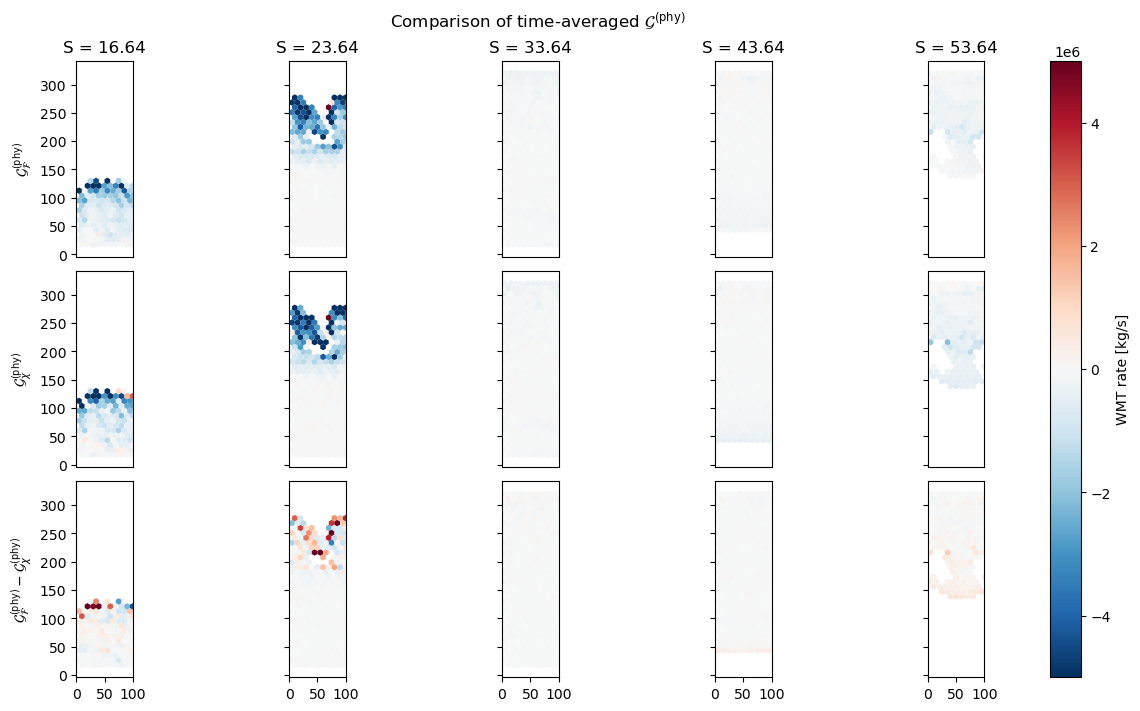

In [44]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([3,10,20,30,40]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j]).mean(dim='Time'), 
                          cmap = 'RdBu_r', vmin= -5e6, vmax = 5e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison of time-averaged $\mathcal{G}^{\text{(phy)}}$');

## A brief attempt at interpretation
6/29/26

*I really am not convinced that my calculation is correct because I don't understand how $\mathcal{G}^\text{(phy)}$ is positive for all salinity classes. Unless my target coordinates have a $\Delta \tilde\lambda$ that is too large, which I will have to check.*

Regardless, I will attempt some amount of interpretation.

Note that $diff = \mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$. This means that 
- RED:  $ diff > 0 \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} > \mathcal{G}_\chi^{\text{(phy)}} \implies$ convergence of a diffusive flux calculatesm ore physical mixing. 
- BLUE: $ diff < 0 \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} < \mathcal{G}_\chi^{\text{(phy)}} \implies$ DVD calculates more vertical physical mixing.

*How is `tracerVertMixTendency` actually calculated?*

In the time average, it appears that $\mathcal{G}_\chi^{\text{(phy)}}$ calculates more transformation via mixing than $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$, particularly in the salinity range of 25-30 g/kg x 1e-3. Notably, this salinity range is where the greatest amount of transformation occurs (we all see that hte cumsum graph has the sharpest increase in this range). 
- Our initial salinity conditions have that salinity linearly incraeses away from the base of the channel (cross-channel dist = 0) such that all S is in the range [15,55]
- The equation of state is linear.
- So would we expect linear mixing too?
- In which case, I'm not following why the greatest amount of mixing is occurring in the 20-30 g/kg x 1e-3 range rather than at $\sim$35, which would be the value of linear mixing?
- Maybe temperature has an effect on density and subsequent mixing?

Next steps:
- The last 2 cells show that the surface salinity transformation $\mathcal{S}$ and the salinty tendency $\partial_t S$ both equal 0 (assuming e-7 is close to machine precision or zero??)
- Which means you should be able to calculate the budget, which requires just the $\mathcal{G}$ terms in the budget.
- Since $\mathcal{M}_\ge$ is defined only by $\lambda \ge \tilde \lambda$ isosurfaces and not some geographic region, then there is no $\Psi$ term.

------------
6/30/26

After correcting for $\Delta \lambda = \lambda_i - \lambda_{i+1}$, we end up with $\mathcal{G}^{\text{(phy)}} < 0$ for all salinity classes in the time average. 

I will first explain the general interpretation of the plots. Then I will explain the plots in the context of the data. 
### Background
>- We define $\mathcal{M}_\ge$ s.t. $\lambda \ge \tilde\lambda$. This means to capture *ALL* water in the domain, $\lambda \to 0$ (i.e., $\lambda$ gets smaller and smaller).
>- This means that when we calculate $\mathcal{G}^{\text{(phy)}}$, which requires taking the derivative $\partial_\lambda \mathcal{G}^{\text{(phy)}}$, we are looking at $\lambda \to 0$, rather than the traditional $\lambda \to \infty$
>- The discretized version is then
-
$$
\begin{equation}
    \frac{\partial \mathcal{G}^{\text{(phy)}}}{\partial \lambda} \approx \frac{\mathcal{G}^{\text{(phy)}}_i - \mathcal{G}^{\text{(phy)}}_{i+1}}{\lambda_i - \lambda_{i+1}}
\end{equation}
$$
>- where $\lambda_i < \lambda_{i+1} \implies \lambda_i - \lambda_{i+1} < 0 \, \forall i$
>- This means that when reading a plot of salinity (y-axis) vs WMT transformation (ie., $\mathcal{G}^{\text{(phy)}}$) (x-axis) where the origin is fresh water, we read from bottom to top.

### Interpretation of $\mathcal{G}^\text{(phy)}$
>- A **positive** $\mathcal{G}^{\text{(phy)}} \implies $ **salinifying**
> >- There is a an **addition** of mass into $\mathcal{M}_\ge$. Fresh water is getting saltier. Water is added to the salty water mass $\mathcal{M}_\ge$.
>- A **negative** $\mathcal{G}^{\text{(phy)}} \implies$ **freshening**
> >- There is a **removal** of mass from $\mathcal{M}_\ge$. Salty water is getting fresher. Water is removed from the salty water mass $\mathcal{M}_\ge$.

### Interpretation of $\partial_\lambda \mathcal{G}^{\text{(phy)}}$
>- Recall we are reading the graph from fresh water (low $\lambda$; $\lambda_i$) to salty water (large $\lambda$; $\lambda_{i+1}$.
>- Again, this comes from the fact that we are "integrating" or taking the derivative where $\lambda \to 0$, rather than $\lambda \to \infty$ based on how we defined $\mathcal{M}_\ge$, rather than $\mathcal{M}_\le$.
>- A **positive** $\partial_\lambda \mathcal{G}^{\text{(phy)}} \implies \mathcal{G}^{\text{(phy)}}_{i+1} > \mathcal{G}^{\text{(phy)}}_i$
> >- The mass flux of water from the $\lambda_{i-1/2}$ salinity class into the $\tilde\lambda_i$ salinity class is *less than* the mass flux of water from the $\tilde\lambda_i$ isalinity class into the $\lambda_{i+1/2}$ salinity class.
> >- There is a *divergence* of mass flux, and the parcel $\mathcal{M}_\ge$ is getting **smaller**.
>- A **negative** $\partial_\lambda \mathcal{G}^{\text{(phy)}} \implies \mathcal{G}^{\text{(phy)}}_{i+1} < \mathcal{G}^{\text{(phy)}}_i$
> >- The mass flux of water from $\lambda_{i-1/2}$ salinity class into the $\tilde\lambda_i$ salinity class is *greater than* the mass flux of water from the $\tilde\lambda_i$ salinity class into the $\lambda_{i+1/2}$ salinity class.
> >- There is a *convergence* of mass flux, and the parcel $\mathcal{M}_\ge$ is getting **larger**.
>- A **zero** $\partial_\lambda \mathcal{G}^{\text{(phy)}} \implies \mathcal{G}^{\text{(phy)}}_{i+1} = \mathcal{G}^{\text{(phy)}}_i$
> >- The mass flux of water from $\lambda_{i-1/2}$ salinity class into the $\tilde\lambda$ salinity class is *exactly equal to* the mass flux of water from the $\tilde\lambda_i$ salinity class into the $\lambda_{i+1/2}$ salinity class.
> >- The parcel $\mathcal{M}_\ge$ does not change in size.
> >- This is what a relative maximum or minimum in these graphs means.
> >

### Interpretation of $\mathcal{G}^{\text{(phy)}}$ plotted wrt salinity class
Analyze the plots from bottom (freshest) to top (saltiest). 
>- We note that in the time-average, $\mathcal{G}^{\text{(phy)}} < 0$ for all salinity classes.
> >- This generally suggests an overall freshening in the domain. A time series of the domain-averaged salinity shows that as the simulation runs, the salinity decreases.
> >- *However*, I do not understand why there is a freshening of the freshest water. That water should, in general, be getting mixed to be saltier. This makes me wonder if my $\Delta \lambda$ choice is too large.
>- There is a relative minima at $S=18.636$ where $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ switches from negative to positive.
> >- For water fresher than 18.636 x 1e-3 g/kg, the water parcel is getting larger, but for water saltier than 18.636 x 1e-3 g/kg, the water parcel is getting smaller.
> >- This suggests mixing of saltier water to fresher water?
>- There is a relative maxima at $S=20.636$ where $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ switches from positive to negative.
> >- For water fresher than 20.636 x 1e-3 g/kg, the water parcel is getting smaller, but for water saltier than 20.636 x 1e-3 g/kg, the water parcel is getting larger.
> >- This suggests fresh water is mixing to salty water?
>- There is a relative minima at $S=25.636$ where $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ switches from negative to positive.
> >- For water fresher than 25.636 x 1e-3 g/kg, th water parcel is getting larger, but for water saltier than 25.636 x 1e-3 g/kg, the water parcel is getting smaller.
> >- This suggests fresh water is mixing into salty water? The salty water parcel is getting smaller. 

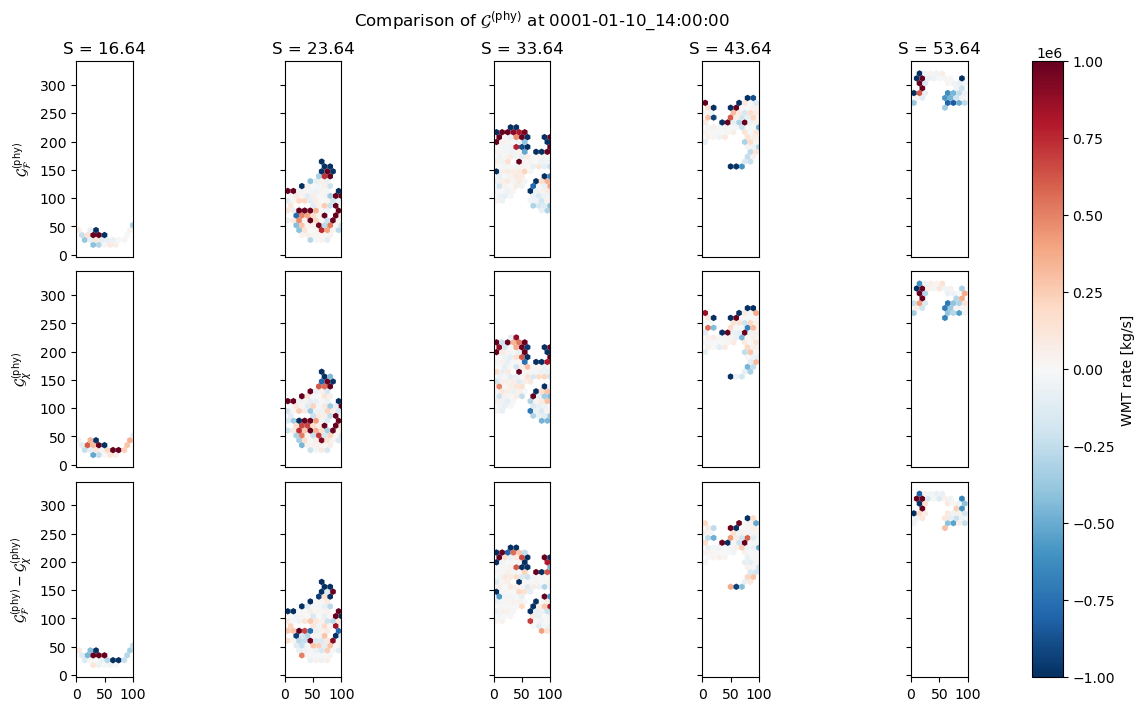

In [45]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([3,10,20,30,40]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j], Time = time_idx), 
                          cmap = 'RdBu_r', vmin= -1e6, vmax = 1e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison of $\mathcal{G}^{\text{(phy)}}$ at ' + str(ds_output.xtime.isel(Time=time_idx).values.item().decode('utf-8')));

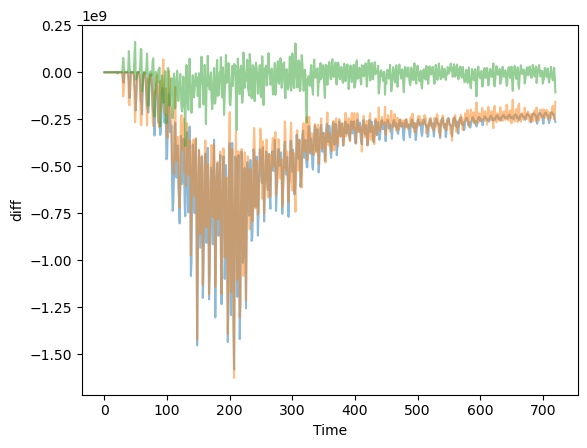

In [46]:
G_phy_comp_ds.G_F_phy_center.sum(dim=['nCells','salinity']).plot(alpha=0.5)
G_phy_comp_ds.G_chi_phy.sum(dim=['nCells','salinity']).plot(alpha=0.5)
G_phy_comp_ds['diff'].sum(dim=['nCells','salinity']).plot(alpha=0.5)

In [47]:
G_phy_comp_ds.G_chi_phy.sum()

<xarray.DataArray 'G_chi_phy' ()> Size: 8B
array(-2.42384129e+11)

In [48]:
G_phy_comp_ds.G_F_phy_center.sum()

<xarray.DataArray 'G_F_phy_center' ()> Size: 8B
array(-2.59688949e+11)

In [49]:
ds_output.salinityTend.sum()

<xarray.DataArray 'salinityTend' ()> Size: 4B
array(-1.2665987e-07, dtype=float32)

In [50]:
ds_output.salinitySurfaceFluxTendency.sum()

<xarray.DataArray 'salinitySurfaceFluxTendency' ()> Size: 4B
array(0., dtype=float32)

In [51]:
ds_output.salinity.isel(Time=0).mean()

<xarray.DataArray 'salinity' ()> Size: 8B
array(35.00279236)

In [52]:
ds_output.salinity.isel(Time=-1).mean()

<xarray.DataArray 'salinity' ()> Size: 8B
array(35.0254364)

In [53]:
G_F_phy_avg

<xarray.DataArray 'G_F_phy_center' (salinity: 43)> Size: 344B
array([ 0.00000000e+00,  0.00000000e+00, -5.98698593e+07, -1.58557585e+08,
       -1.41938357e+08, -3.01356694e+08, -1.87588397e+08, -1.33347721e+08,
       -1.55507727e+08, -1.96379217e+08, -2.89938354e+08, -2.91175067e+08,
       -3.17199564e+08, -2.85139201e+08, -2.49671810e+08, -1.71171709e+08,
       -1.38104404e+08, -9.97115245e+07, -5.77860792e+07, -3.28644309e+07,
       -1.76813091e+07, -1.35831916e+07, -1.03248412e+07, -9.57843041e+06,
       -9.34483037e+06, -1.12895535e+07, -1.27575937e+07, -1.03257540e+07,
       -1.21868209e+07, -1.19493941e+07, -1.31005225e+07, -1.31511606e+07,
       -1.53653343e+07, -1.55299274e+07, -1.63911687e+07, -1.92090227e+07,
       -2.06176941e+07, -2.11396325e+07, -2.21664577e+07, -4.50565417e+07,
       -4.15912804e+07, -7.67392665e+06,  0.00000000e+00])
Coordinates:
  * salinity  (salinity) float64 344B 13.64 14.64 15.64 ... 53.64 54.64 55.64

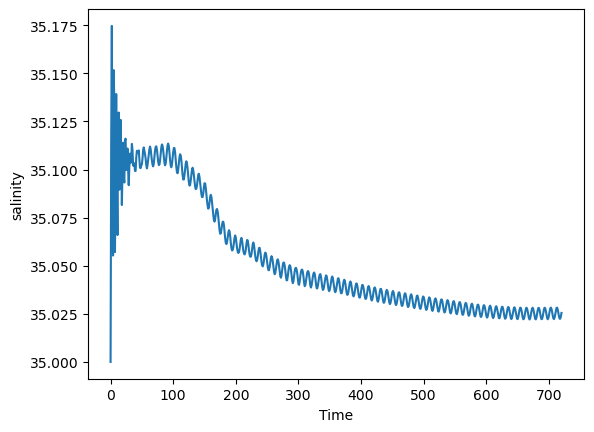

In [54]:
salinity_ts = ds_output.salinity.mean(dim=['nCells','nVertLevels'])
salinity_ts.plot()

In [56]:
# 7/1/26 Why is G_F_phy vs salinity always negative for all salinity classes?

# look at the og salinity vertical mixing tendency, remap that to salinity, look at the sign
ds_check = ds_output.salinityVertMixTendency.mean(dim=['Time','nCells'])

# interpolate the DVD vertical physical mixing onto nVertLevels
grid_check = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)

ds_check = ds_output
ds_check['salinity_P1'] = grid_check.interp(ds_check.salinity, 'Z', boundary = 'extend')

# remap from nVertLevels coords to salinity coords
ds_F_transformed = grid_check.transform(ds_check.salinityVertMixTendency,
                                        'Z',
                                        ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow remapping to salinity
                                        method= 'linear',
                                        target_data = ds_check.salinity)
# rename the nVertLevelsP1 to salinity
ds_F_transformed = ds_F_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='salinityVertMixTendency')

# transform temperature in salinity coordinates
ds_T_transformed = grid_check.transform(ds_check.temperature,
                                        'Z',
                                        ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow remapping to salinity
                                        method= 'linear',
                                        target_data = ds_check.salinity)
ds_T_transformed = ds_T_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='Temperature')

# transform chi_num_salinity into salnity coordinates
ds_chi_num_transformed = grid_check.transform(ds_check.chiSpurSaltBR08,
                                              'Z',
                                              ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow for remapping to center salinity
                                              method = 'linear',
                                              target_data = ds_check.salinity)
ds_chi_num_transformed = ds_chi_num_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='chi_num_salt')

ds_chi_phy_transformed = grid_check.transform(grid_check.interp(ds_check.chiPhyVerSalt, 'Z', boundary='extend'),
                                              'Z',
                                              ds_check['salinity'].mean(dim=['nCells','Time']), # target coordinates in salinity that allow for remapping to center salinity
                                              method = 'linear',
                                              target_data = ds_check.salinity)
ds_chi_phy_transformed = ds_chi_phy_transformed.rename({'nVertLevels' : 'salinity'}).to_dataset(name='chi_phy_salt')

/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: divide by zero encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: divide by zero encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: divide by zero encountered in _interp_1d_linear
  return self.ufunc

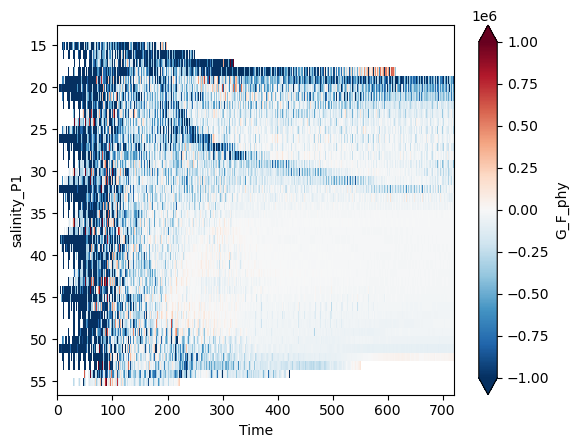

In [57]:
G_phy_comp_ds.G_F_phy.mean(dim='nCells').plot(y='salinity_P1',vmin=-1e6, vmax=1e6, cmap='RdBu_r')
plt.gca().invert_yaxis()

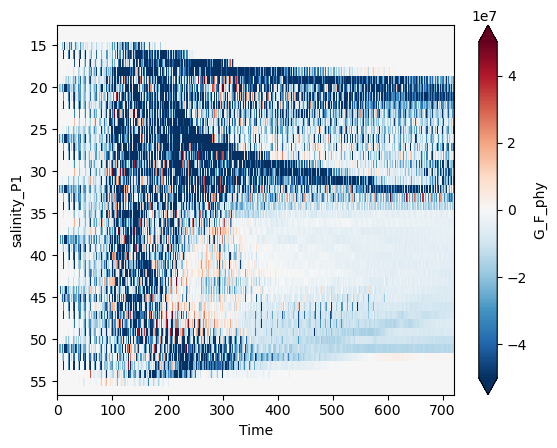

In [58]:
G_phy_comp_ds.G_F_phy.sum(dim='nCells').plot(y='salinity_P1',cmap='RdBu_r',vmin=-5e7,vmax=5e7)
plt.gca().invert_yaxis()

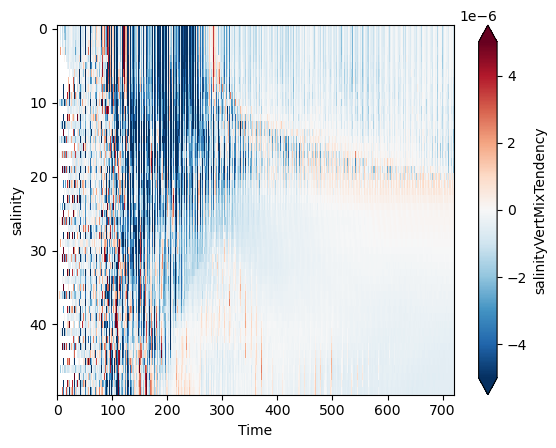

In [59]:
ds_F_transformed.salinityVertMixTendency.mean(dim='nCells').plot(y='salinity',vmin=-5e-6, vmax=5e-6, cmap='RdBu_r')
plt.gca().invert_yaxis()

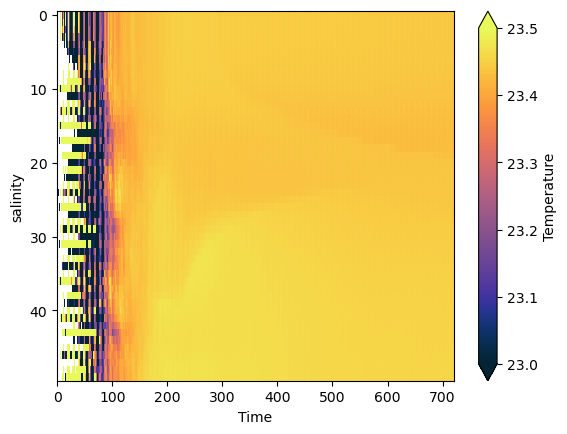

In [60]:
ds_T_transformed.Temperature.mean(dim='nCells').plot(y='salinity', cmap = cmo.thermal,vmin=23,vmax=23.5)
plt.gca().invert_yaxis()

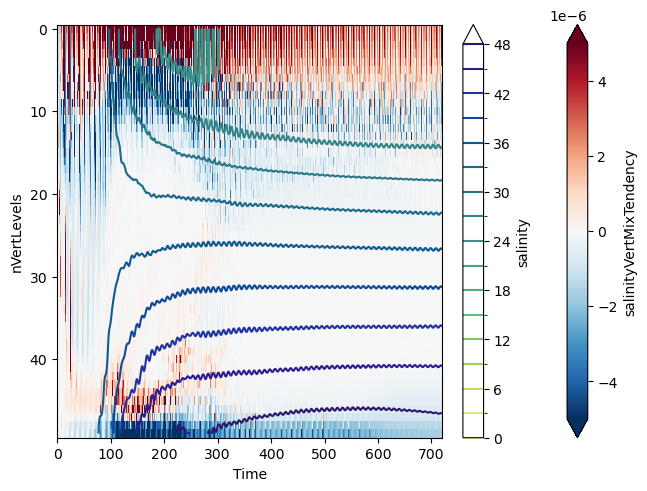

In [61]:
fig, ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ds_output.salinityVertMixTendency.mean(dim='nCells').plot(y='nVertLevels',vmin=-5e-6, vmax=5e-6,cmap='RdBu_r', add_colorbar=True)
ds_output.salinity.mean(dim='nCells').plot.contour(y='nVertLevels',levels=ds_F_transformed.salinity[::3],add_colorbar=True, cmap = cmo.haline_r)
ax.invert_yaxis()

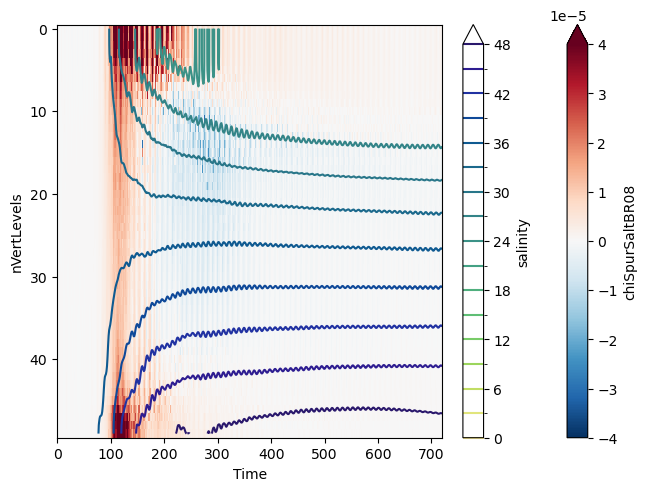

In [62]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ds_dvd.chiSpurSaltBR08.mean(dim='nCells').plot(y='nVertLevels', vmin=-4e-5, vmax=4e-5,cmap='RdBu_r')
ds_output.salinity.mean(dim='nCells').plot.contour(y='nVertLevels',levels=ds_F_transformed.salinity[::3],add_colorbar=True, cmap = cmo.haline_r)
ax.invert_yaxis()

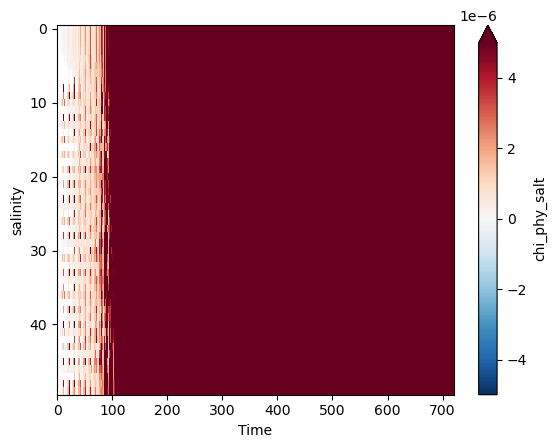

In [63]:
ds_chi_phy_transformed.chi_phy_salt.mean(dim='nCells').plot(y='salinity',vmin=-5e-6, vmax=5e-6, cmap='RdBu_r')
plt.gca().invert_yaxis()

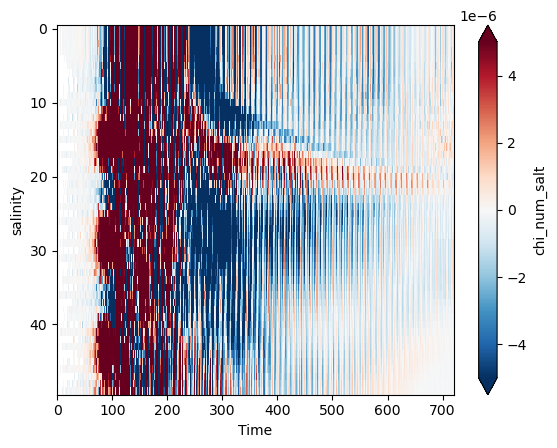

In [64]:
ds_chi_num_transformed.chi_num_salt.mean(dim='nCells').plot(y='salinity',vmin=-5e-6, vmax=5e-6, cmap='RdBu_r')
plt.gca().invert_yaxis()